# 옵티마이져 성능 비교  iris 분류

In [40]:
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn
import torch

scaler = StandardScaler()
iris = load_iris()
X = iris.data
y = iris.target

x_train,x_test,y_train,y_test = train_test_split(X,y,stratify=y,random_state=42)
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

x_train_t = torch.FloatTensor(x_train)
y_train_t = torch.LongTensor(y_train)

train_dataset = TensorDataset(x_train_t,y_train_t)
train_loader = DataLoader(train_dataset,batch_size=24)

class RegressionIris(nn.Module):
    def __init__(self, input_dim, hidden_dim,output_dim):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, output_dim)
    def forward(self, x):
        x = nn.ReLU()(self.fc1(x))
        x = nn.ReLU()(self.fc2(x))
        output = self.fc3(x)
        return output

In [41]:
# 다중분류 크로스엔트로피로스
from torch.optim import SGD,Adagrad,RMSprop,Adam
model = RegressionIris(4, 16, 3)
criterion = nn.CrossEntropyLoss()

In [42]:
from tqdm import tqdm
epochs = 200; loss_list = []
sgd = SGD(model.parameters(),momentum=0)
momentum = SGD(model.parameters(),momentum=0.9)
adagrad = Adagrad(model.parameters())
rmsprop = RMSprop(model.parameters())
adam = Adam(model.parameters())
optim_lists = [sgd,momentum,adagrad,rmsprop,adam]

for optim in tqdm(optim_lists):
    sub_loss_list = []
    for epoch in range(epochs):
        total_loss = 0.0
        for x,y in train_loader:
            optim.zero_grad()
            predict = model(x)
            loss = criterion(predict, y)
            loss.backward()
            optim.step()

            total_loss += loss.item()
        sub_loss_list.append(total_loss / len(train_loader))
    loss_list.append(sub_loss_list)
    

100%|██████████| 5/5 [00:06<00:00,  1.24s/it]


In [43]:
sgd.__class__.__name__

'SGD'

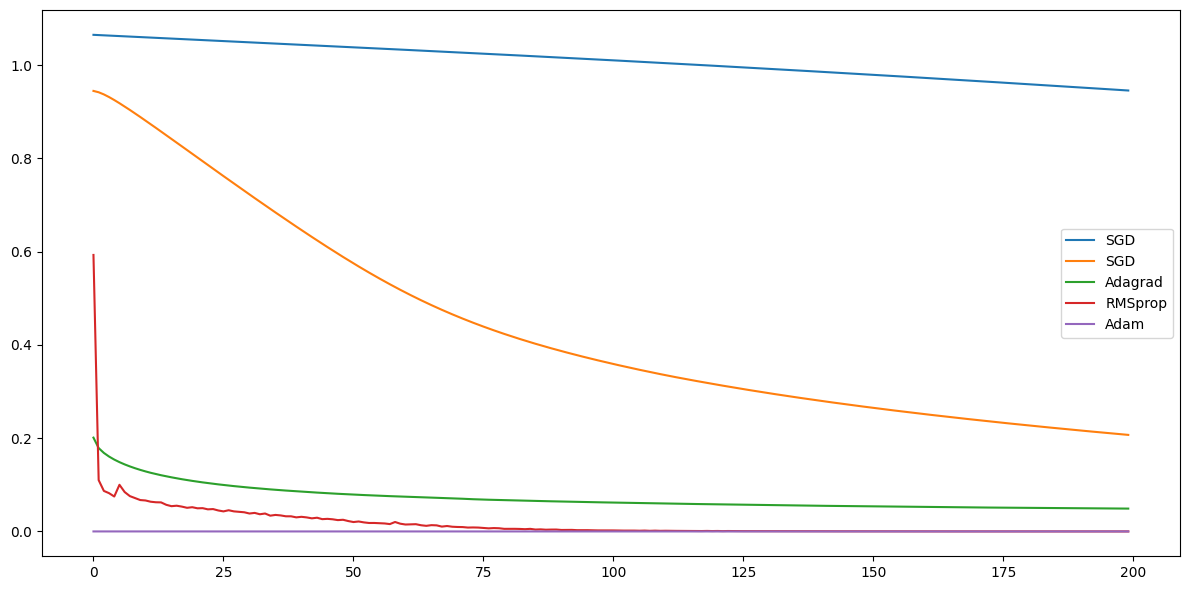

In [44]:
import matplotlib.pyplot as plt
fig,ax = plt.subplots(figsize=(12,6))
for optim_loss, optim in zip(loss_list,optim_lists):
    ax.plot(range(epochs), optim_loss, label = optim.__class__.__name__ )
plt.legend()
plt.tight_layout()
plt.show()